In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="4"

In [2]:
# Find the project root
import sys
import os

from instant_aiv.models.NNpp import *
from instant_aiv.models.metrics import *
from instant_aiv.manage.plots import *
from instant_aiv.manage.dataloader import *

# Libraries
import argparse
import numpy as np
import scipy.io
import time
import gc
import pandas as pd
import pickle


#Plots
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

import os
import numpy as np
import jax
from jax import jit, grad, vmap, value_and_grad,jvp

import jax.numpy as jnp
import optax

from typing import Tuple
import time


import h5py
from typing import List, Dict
from pyDOE import lhs
import tqdm
import scipy.integrate as integrate
from matplotlib.ticker import FormatStrFormatter


# Tunning Parameters

In [3]:
parser = argparse.ArgumentParser(description='Tunning_parameters')
parser.add_argument('--run_type'   , type=str  , default='Permeability')
parser.add_argument('--mode'       , type=str  , default='Initialization')
parser.add_argument('--num_layer'  , type=int  , default=6)
parser.add_argument('--width_layer', type=int  , default=50)
parser.add_argument('--train_ratio' , type=float, default=0.5)
parser.add_argument('--Run_MODE'   , type=str  , default='Plots')
parser.add_argument('--use_RBA'    , type=bool , default=True)
parser.add_argument('--batch_size' , type=int  , default=10000)
parser.add_argument('--num_gsteps' , type=int  , default=500*(10**3))
parser.add_argument('--Name' , type=str  , default='Init_K')
parser.add_argument('--normalization' , type=str  , default='chebyshev5')
parser.add_argument('--Equal_Batch' , type=bool  , default=True)
parser.add_argument('--optimizer' , type=str  , default='AdamW')


parser.add_argument('--k_samp' , type=float  , default=2.0)
parser.add_argument('--c_samp' , type=float  , default=0.5)
parser.add_argument('--lr_lambdas_0' , type=float  , default=0.1)
parser.add_argument('--gamma' , type=float  , default=0.999)

parser.add_argument('--Weight_Norm'    , type=int , default=1)
parser.add_argument('--Mod_MLP'    , type=int , default=0)
parser.add_argument('--Use_ResNet'    , type=int , default=1)
parser.add_argument('--Adaptive'    , type=int , default=1)
parser.add_argument('--Light'    , type=int , default=0)
args, unknown = parser.parse_known_args()
for arg, value in vars(args).items():
    print(f'{arg}: {value}')

run_type: Permeability
mode: Initialization
num_layer: 6
width_layer: 50
train_ratio: 0.5
Run_MODE: Plots
use_RBA: True
batch_size: 10000
num_gsteps: 500000
Name: Init_K
normalization: chebyshev5
Equal_Batch: True
optimizer: AdamW
k_samp: 2.0
c_samp: 0.5
lr_lambdas_0: 0.1
gamma: 0.999
Weight_Norm: 1
Mod_MLP: 0
Use_ResNet: 1
Adaptive: 1
Light: 0


In [4]:
Run_type = args.run_type
Mode=args.mode
#ResNet Architecures
Use_ResNet=args.Use_ResNet 
Adaptive=args.Adaptive 
Light=args.Light 
num_layer=args.num_layer

if Use_ResNet:
    num_layer=int((num_layer+2)/2)

width_layer=args.width_layer
layers={
    "k" :[4]  + num_layer*[width_layer] + [1],
}
layers_ref=np.copy(layers["k"])
layers_1=np.copy(layers["k"])

train_ratio=args.train_ratio

Details=f'Permeability_{args.Name}'

Run_MODE=args.Run_MODE

print('Model Architecture:')
print(layers)

activation = 'sin'
initialization = 'xavier'
normalization  = args.normalization
loss_metric ='L2'
Weight_Norm =args.Weight_Norm#Weight Normalization
use_RBA=args.use_RBA

normalize_outputs=False
init_zero=True

#Optimization
num_gsteps  = args.num_gsteps
batch_size = args.batch_size

#learning and RBA
lam_min=0.0
lr0=2*10**(-3)
lrf=5*10**(-5)
lr_lambdas_0=args.lr_lambdas_0
gamma=args.gamma
max_lambda=lr_lambdas_0/(1-gamma)
print(f'Max RBA will be:{max_lambda}')
T_e=num_gsteps
decay_rate=0.9
decay_step=0
seed_np=1234
key = jax.random.PRNGKey(seed_np)
key, subkey = jax.random.split(key)

dataset_name = f'{Details}'




Model Architecture:
{'k': [4, 50, 50, 50, 50, 1]}
Max RBA will be:99.99999999999991


In [5]:
project_root = find_package_directory() # if error please define the root package directly (e.g. project_root='/users/.../' )
data_path=project_root+'/Data/Permeabilities/Mid_smooth.mat'
save_path=project_root+f'/Results/{Run_type}/'
big_data_path=save_path
print(f'Analizing:{data_path}')
print(f'Details:{Details}')
print(f'dataset_name:{dataset_name}')


Analizing:/users/jdtoscan/Documents/Papers/Instant_AIV//Data/Permeabilities/Mid_smooth.mat
Details:Permeability_Init_K
dataset_name:Permeability_Init_K


In [6]:
use_RBA=int(use_RBA)
print(f'Using RBA:{use_RBA}')

Using RBA:1


## Settings


In [7]:
# Fetching activation function
activation_fn = ACTIVATION_FUNCTIONS.get(activation.lower())

# Fetching normalization functions and metrics
norm_settings = NORMALIZATION_FUNCTIONS.get(normalization.lower())
norm_fn = norm_settings['fn']
Norm_metric1 = norm_settings['metric1']
Norm_metric2 = norm_settings['metric2']

# Fetching error function
Error_fn = ERROR_FUNCTIONS.get(loss_metric.lower())

if normalization.lower()=='fourier_time':
    for key in layers.keys():
        embed_size=layers[key][1]
        input_dim=layers[key][0]-1
        output_dim=layers[key][-1]
        layers[key]=(num_layer)*[(2*input_dim)*(embed_size//(2*input_dim))+input_dim+1]+ [output_dim]
elif normalization.lower()=='chebyshev12':
    for key in layers.keys():
        embed_size=layers[key][1]
        input_dim=layers[key][0]*12
        output_dim=layers[key][-1]
        layers[key]=[input_dim]+(num_layer)*[embed_size]+ [output_dim]
elif normalization.lower()=='chebyshev5':
    for key in layers.keys():
        embed_size=layers[key][1]
        input_dim=layers[key][0]*5
        output_dim=layers[key][-1]
        layers[key]=[input_dim]+(num_layer)*[embed_size]+ [output_dim]
elif normalization.lower()=='hybrid':
    for key in layers.keys():
        embed_size=layers[key][1]
        input_dim=layers[key][0]*12
        output_dim=layers[key][-1]
        layers[key]=[input_dim]+(num_layer)*[embed_size]+ [output_dim]
print(f'New architecture:{layers}')


New architecture:{'k': [20, 50, 50, 50, 50, 1]}


In [8]:
# %%
np.random.seed(seed_np)
params_NN = init_params_dict(layers, initialization,Use_ResNet)
alpha=0.1
beta=5.0
params=(alpha,beta,params_NN)

# Model selection
pinn_fn =select_model(WN=Weight_Norm,Use_ResNet=Use_ResNet,Adaptive=Adaptive,Light=Light)
print(f'The model will be: {pinn_fn}')

# Optimizer Initialization
optimizer,decay_step = initialize_optimizer(lr0, decay_rate, lrf, decay_step, T_e,optimizer_type=args.optimizer)
opt_state = optimizer.init(params)


# %%
M1= Norm_metric1
M2= Norm_metric2
print('Norm metrics:',M1,M2)


You selected: Network mlp with degree(if KAN) 5, initialization xavier,Use_ResNet 1
The model will be: <function WN_ResNet_adaptive at 0x7f2534f363e0>
Optimizer adamw
Weight decay: 1e-05
The decay step will be 14280.829309876939
Norm metrics: <function <lambda> at 0x7f253a4c8680> <function <lambda> at 0x7f253a4c8720>


## Create Folders

In [9]:
subdirs = ["General","Imgs", "Big_Data", "Data", "Flow_rate", "Errors"]
paths = create_and_return_directories(save_path, dataset_name, subdirs)
print(dataset_name)
result_path = paths["General"]
images_path = paths["Imgs"]
big_path = paths["Big_Data"]
Video_path = paths["Flow_rate"]
errors_path = paths["Errors"]


The general path is: /users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/General/
The imgs path is: /users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/Imgs/
The big data path is: /users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/Big_Data/
The data path is: /users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/Data/
The flow rate path is: /users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/Flow_rate/
The errors path is: /users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/Errors/
Permeability_Init_K


#### Colors (optional)

In [10]:
cmap = 'cool'
num_colors=8
# Create a colormap
cmap = plt.get_cmap(cmap)
colors = [cmap(i) for i in np.linspace(0, 1, num_colors)]
colors=colors[:num_colors//4]+colors[3*num_colors//4:]
print(len(colors))
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['font.size'] = 20

4


# Non-Dimensional values

In [11]:
k1=1*10**(-12)#mm2
D1=3.8*10**(-10)#mm2/s
k2=1*10**(-16)
D2=2.3*10**(-10)
nu_e=7*10**(-7)
rho=993
h=0.00034 #Maximum length by 100
L_char=h
U_char=0.1#mm/min
D_char=2.3000001e-10#mm2/s
k_char=9.99999982e-15*10
U_char=U_char*(1/1000)*(1/60)#m/s
T_char=L_char/U_char
C_char=1
Pef=U_char*L_char/D_char
mms=10**6
L_char=L_char
U_char=U_char
L_char0=np.copy(L_char)
U_char0=np.copy(U_char)
print(T_char,L_char,U_char,C_char,D_char)
print(Pef)
T_SI=1
L_SI=1000
D_SI=1
U_SI=1000
K_SI=10**6
SI_fact_steady=np.array([1/T_SI,1/L_SI,1/L_SI,1/L_SI,1/K_SI])
SI_fact=np.array([1/T_SI,1/L_SI,1/L_SI,1/L_SI,1])
non_dim_fact_steady=np.array([1/T_char,1/L_char,1/L_char,1/L_char,1/k_char])
non_dim_fact=np.array([1/T_char,1/L_char,1/L_char,1/L_char,1])
print(non_dim_fact)

204.00000000000003 0.00034 1.6666666666666667e-06 1 2.3000001e-10
2.4637680088216807
[4.90196078e-03 2.94117647e+03 2.94117647e+03 2.94117647e+03
 1.00000000e+00]


## Load Data


In [12]:
df = scipy.io.loadmat(data_path)
print(df.keys())
print(df['units'])


dict_keys(['__header__', '__version__', '__globals__', 'mat_perm_map1', 'mat_perm_map11', 'mat_perm_map3', 'mat_perm_map5', 'note', 'units', 'variables'])
[[array(['mm'], dtype='<U2') array(['mm'], dtype='<U2')
  array(['mm'], dtype='<U2') array(['mm^2'], dtype='<U4')]]


In [13]:
all_data = df['mat_perm_map3']
# Display the headers/column names
print(all_data.shape)

(480009, 4)


In [14]:

txyzDuvwuvwk=np.hstack((all_data[:,0:1],all_data[:,:3],10**(all_data[:,3:4])))
print('Min and max for txyzDuvwuvwk',txyzDuvwuvwk.shape)
print(txyzDuvwuvwk.min(0))
print(txyzDuvwuvwk.max(0))
txyzDuvwuvwk=txyzDuvwuvwk*SI_fact_steady
print('SI:Min and max for txyzDuvwuvwk',txyzDuvwuvwk.shape)
print(txyzDuvwuvwk.min(0))
print(txyzDuvwuvwk.max(0))
txyzDuvwuvwk=txyzDuvwuvwk*non_dim_fact_steady
print('ND:Min and max for txyzDuvwuvwk',txyzDuvwuvwk.shape)
print(txyzDuvwuvwk.min(0))
print(txyzDuvwuvwk.max(0))


Min and max for txyzDuvwuvwk (480009, 5)
[1.9e+00 1.9e+00 3.7e+00 1.4e+00 1.0e-10]
[1.70e+01 1.70e+01 1.16e+01 1.17e+01 1.00e-06]
SI:Min and max for txyzDuvwuvwk (480009, 5)
[1.89999998e+00 1.89999998e-03 3.70000005e-03 1.39999998e-03
 1.00000001e-16]
[1.70000000e+01 1.70000000e-02 1.16000004e-02 1.16999998e-02
 9.99999997e-13]
ND:Min and max for txyzDuvwuvwk (480009, 5)
[9.31372537e-03 5.58823522e+00 1.08823531e+01 4.11764699e+00
 1.00000003e-03]
[ 0.08333333 50.         34.11764818 34.41176414 10.00000015]


In [15]:
k1=1*10**(-12)#m2
D1=3.8*10**(-10)#m2/s
k2=1*10**(-16)
D2=2.3*10**(-10)
nu_e=7*10**(-7)
rho=993
h=0.00034 #Maximum length by 100
L_char=h
U_char=0.1#mm/min
D_char=2.2504406369964327e-10
U_char=U_char*(1/1000)*(1/60)#m/s
T_char=L_char/U_char
C_char=1
k_char=1e-14
mms=10**6
L_char=L_char
U_char=U_char
L_char0=np.copy(L_char)
U_char0=np.copy(U_char)
print(T_char,L_char,U_char,C_char,D_char)
rec_fact=np.array([T_char/60,L_char,L_char,L_char,U_char,U_char,U_char,(U_char/mms)**2*rho,C_char])
print(rec_fact)

204.00000000000003 0.00034 1.6666666666666667e-06 1 2.2504406369964327e-10
[3.40000000e+00 3.40000000e-04 3.40000000e-04 3.40000000e-04
 1.66666667e-06 1.66666667e-06 1.66666667e-06 2.75833333e-21
 1.00000000e+00]


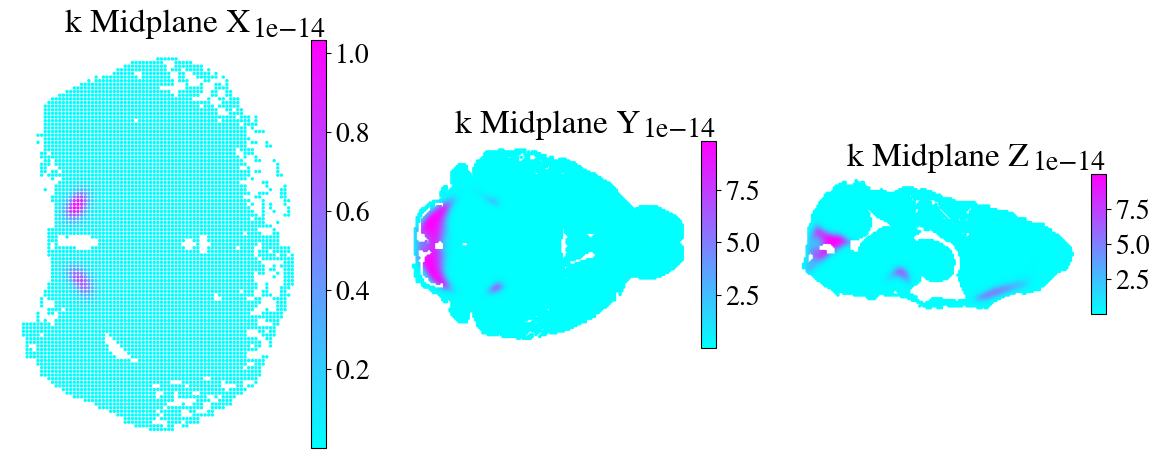

In [16]:
X_plot = txyzDuvwuvwk
t,x, y, z,k = (
                X_plot[:,0],
                X_plot[:,1],
                X_plot[:,2],
                X_plot[:,3],
                X_plot[:,4],)
# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.1  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [k*k_char]  # Use the scalar field for coloring
variable_names = ['k']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 14))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} Midplane {["X", "Y", "Z"][j]}')
        #ax.set_xlabel(xlabel)
        #ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('off')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.show()


In [17]:
Data=np.hstack((t[:,None],
                x[:,None],
                y[:,None],
                z[:,None],
                k[:,None]*k_char,))
t,x, y, z,k = ( Data[:,0],
                Data[:,1],
                Data[:,2],
                Data[:,3],
                Data[:,4],)
print(Data.shape)
print(Data.min(0))
print(Data.max(0))

(480009, 5)
[9.31372537e-03 5.58823522e+00 1.08823531e+01 4.11764699e+00
 1.00000003e-17]
[8.33333333e-02 5.00000000e+01 3.41176482e+01 3.44117641e+01
 1.00000002e-13]


In [18]:
offset=10
K=k/k_char
log_K=np.log(K)-offset
print(log_K.min(0))
print(log_K.max(0))
Data=np.hstack((t[:,None],
                x[:,None],
                y[:,None],
                z[:,None],
                k[:,None],
                log_K[:,None]))
print(Data.shape)
print(Data.min(0))
print(Data.max(0))
offset=offset+np.log(10)

-16.907755247630703
-7.697414891530712
(480009, 6)
[ 9.31372537e-03  5.58823522e+00  1.08823531e+01  4.11764699e+00
  1.00000003e-17 -1.69077552e+01]
[ 8.33333333e-02  5.00000000e+01  3.41176482e+01  3.44117641e+01
  1.00000002e-13 -7.69741489e+00]


In [19]:
log_K2=-log_K
lb_k=0.9*log_K2.min()
ub_k=1.1*(log_K2.max()-log_K2.min())
print(lb_k,ub_k)
print(-lb_k,-(lb_k+ub_k))

6.927673402377641 10.13137439170999
-6.927673402377641 -17.059047794087633


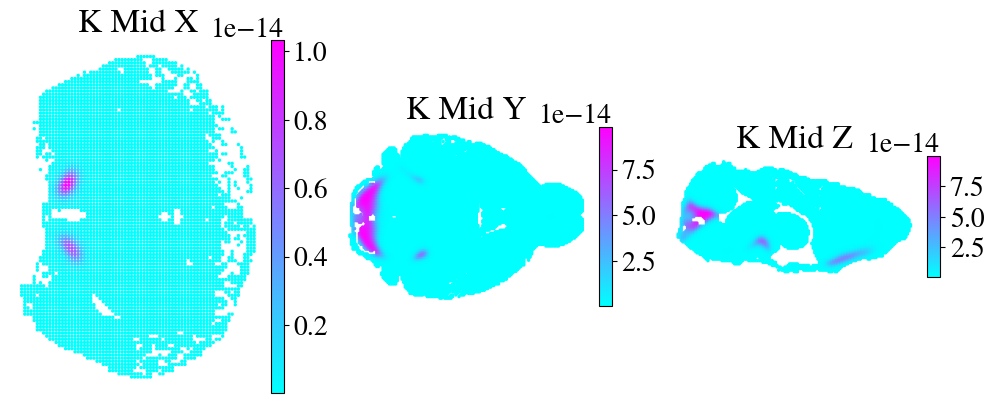

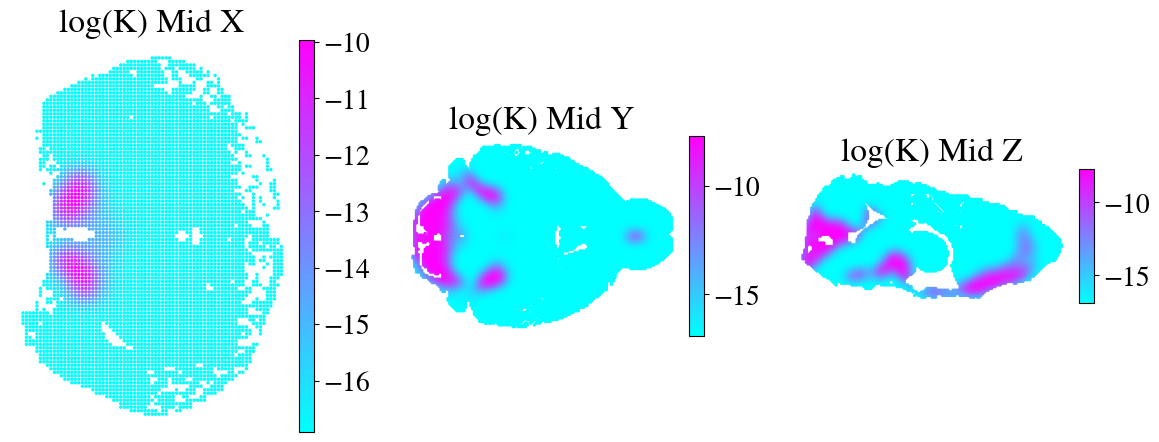

In [20]:
t,x, y, z, K, log_K = Data[:,0], Data[:,1], Data[:,2], Data[:,3], Data[:,4], Data[:,5]
# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

tolerance = 0.1  # Adjust based on your dataset's spread

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# Prepare for visualization

# Variables for plotting
variables = [K, log_K]  # Use the scalar field for coloring
variable_names = ['K','log(K)']

# Visualization
for i, var in enumerate(variables):
    fig = plt.figure(figsize=(12, 8))  # Adjust size as needed

    for j in range(3):
        ax = fig.add_subplot(1, 3, j + 1)
        if j == 0:
            filter_mask = x_midplane_filter
            scatter_x, scatter_y = y[filter_mask], z[filter_mask]
            xlabel, ylabel = 'Y', 'Z'
        elif j == 1:
            filter_mask = y_midplane_filter
            scatter_x, scatter_y = x[filter_mask], z[filter_mask]
            xlabel, ylabel = 'X', 'Z'
        else:  # j == 2
            filter_mask = z_midplane_filter
            scatter_x, scatter_y = x[filter_mask], y[filter_mask]
            xlabel, ylabel = 'X', 'Y'

        # Use the scalar field for coloring
        scatter = ax.scatter(scatter_x, scatter_y, c=var[filter_mask], cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} Mid {["X", "Y", "Z"][j]}')
        #ax.set_xlabel(xlabel)
        #ax.set_ylabel(ylabel)
        ax.axis('equal')
        ax.axis('off')  # Change to 'off' if you prefer no axis

        # Adding a colorbar to each subplot
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)

plt.tight_layout()
plt.show()


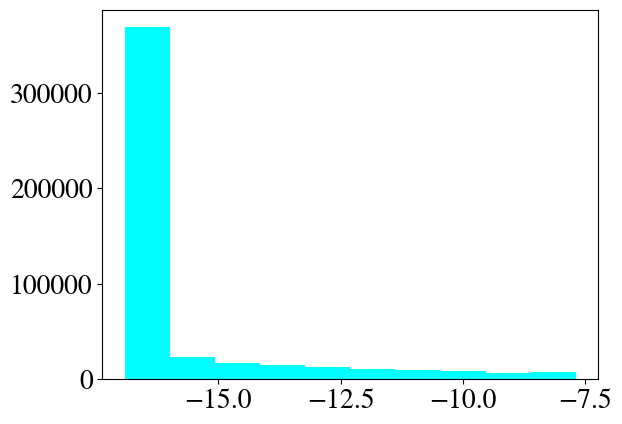

In [21]:
plt.hist(log_K)
plt.show()

In [22]:
high_idx=np.argwhere(log_K>-14).flatten()
low_idx =np.argwhere(log_K<=-14).flatten()
data_high=Data[high_idx]
data_high=np.hstack((data_high[:,:4],data_high[:,5:6]))
data_low =Data[low_idx]
data_low=np.hstack((data_low[:,:4],data_low[:,5:6]))
X_GT=np.hstack((Data[:,:4],Data[:,5:6]))
print(X_GT.shape,data_high.shape,data_low.shape)

(480009, 5) (67725, 5) (412284, 5)


## Data Analytics

In [23]:
# %%
print(f'Bounds for Data high with {data_high.shape} points:')
print(np.min(data_high,axis=0))
print(np.max(data_high,axis=0))
print(f'Bounds for Data low Data with {data_low.shape} points:')
print(np.min(data_low,axis=0))
print(np.max(data_low,axis=0))
print(f'Bounds for Data Eval with {X_GT.shape} points:')
print(np.min(X_GT,axis=0))
print(np.max(X_GT,axis=0))  
# %%
dataset = {
    'high': data_high,
    'low': data_low,
    'GT': X_GT
}
lam = {
    'high': 100,
    'low': 10,
    'GT': 1
}
neq = {
    'high': 1,
    'low': 1,
    'GT': 1
}


Bounds for Data high with (67725, 5) points:
[ 9.31372537e-03  5.58823522e+00  1.29411768e+01  7.94117661e+00
 -1.39998637e+01]
[ 0.07401961 44.41176583 28.5294112  30.88235294 -7.69741489]
Bounds for Data low Data with (412284, 5) points:
[ 9.31372537e-03  5.58823522e+00  1.08823531e+01  4.11764699e+00
 -1.69077552e+01]
[  0.08333333  50.          34.11764818  34.41176414 -14.00001077]
Bounds for Data Eval with (480009, 5) points:
[ 9.31372537e-03  5.58823522e+00  1.08823531e+01  4.11764699e+00
 -1.69077552e+01]
[ 0.08333333 50.         34.11764818 34.41176414 -7.69741489]


# RBA_Weights

Lenght of high dataset: 67725
Lenght of low dataset: 412284
Lenght of GT dataset: 480009
Batch size for high dataset: 10000
Batch size for low dataset: 10000
Lambda shape for high dataset: (67725, 1)
Lambda shape for low dataset: (412284, 1)


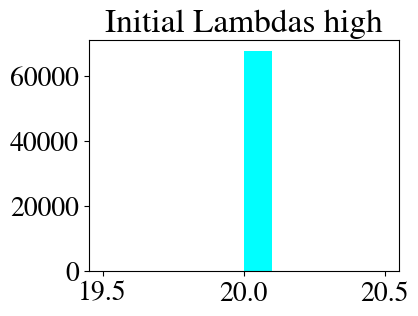

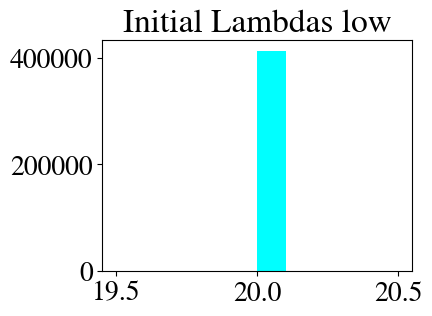

In [24]:
lenghts=[]
for key in dataset.keys():
    lenghts.append(len(dataset[key]))
    print(f'Lenght of {key} dataset: {len(dataset[key])}')
N_train=int(np.max(lenghts))
if batch_size<0:
    batch_size=N_train
All_its=int(np.ceil(N_train/batch_size))
BATCH_SIZES = {}


for key in dataset.keys():
    if not(key == 'GT' or key == 'Test'):
        BATCH_SIZES[key] = int(np.ceil(len(dataset[key]) / All_its))
        if args.Equal_Batch:
            BATCH_SIZES[key]=batch_size
        print(f'Batch size for {key} dataset: {BATCH_SIZES[key]}')
    

lambdas={}
for key in dataset.keys():
    np.random.seed(seed_np)
    if not(key == 'GT' or key == 'Test'):
        lambdas[key] = np.random.uniform(0, 1, size=(len(dataset[key]), neq[key]))
        if init_zero:
            lambdas[key]= lambdas[key]*0+max_lambda/5
        print(f'Lambda shape for {key} dataset: {lambdas[key].shape}')



# %%
for key in dataset.keys():
    if not(key == 'GT' or key == 'Test'):
        fig, ax = plt.subplots(figsize =(4, 3))
        ax.hist(lambdas[key])
        ax.set_title(f"Initial Lambdas {key}")
         



# Loss Functions

In [25]:
def K_model(params):
    alpha,beta,params_NN=params
    # Neural Network
    fn={
        "k" :lambda x: pinn_fn(params_NN["k"], jnp.array([0.0,x[1],x[2],x[3]]), M1, M2,activation_fn,norm_fn),
    }

    k= (
                 lambda x:-(lb_k+ub_k*jax.nn.sigmoid(fn["k"](x)[0]))
                 )
    return k


## Training

In [26]:
@jit
def update_stage(params, lambdas,lam,Pe, opt_state, dataset: Dict[str, np.ndarray], batch_indices: Dict[str, np.ndarray]):
    # Compute the predictions based on the given functions.
    def compute_prediction(X, funcs):
        result = jnp.zeros((X.shape[0], len(funcs)))
        for i, fn in enumerate(funcs):
            result = result.at[:, i].set(vmap(fn, (0))(X[:, :layers_ref[0]]).flatten())
        return result
    def project_simplex(lam_f):
        return (lam_f/(jnp.sum(lam_f, axis=0)+10**(-8)))*len(lam_f)
    def loss_fn(params):
        # eqn error
        K_fx    = K_model(params)
        #  Data K
        pred_high   =compute_prediction(dataset['high'], [K_fx])
        r_pred_high = jnp.abs(pred_high-dataset['high'][:,4:5])
    
        lam_high = (gamma) * lambdas['high'][batch_indices['high']] + lr_lambdas_0 * r_pred_high / jnp.max(r_pred_high, axis=0)
        lambdas['high'] = lambdas['high'].at[batch_indices['high']].set(lam_high)
        lam_high=project_simplex(lam_high)
        lam_high = lam_high*use_RBA+1

        pred_low   =compute_prediction(dataset['low'], [K_fx])
        r_pred_low = jnp.abs(pred_low-dataset['low'][:,4:5])
    
        lam_low = (gamma) * lambdas['low'][batch_indices['low']] + lr_lambdas_0 * r_pred_low / jnp.max(r_pred_low, axis=0)
        lambdas['low'] = lambdas['low'].at[batch_indices['low']].set(lam_low)
        lam_low=project_simplex(lam_low)
        lam_low = lam_low*use_RBA+1

        
        loss_vals = {
            'high' :  lam['high']*Error_fn(r_pred_high, 0.0, weight=lam_high),
            'low'  :  lam['low']*Error_fn(r_pred_low, 0.0, weight=lam_low),
        }
        Error_vals = {
            'high' :  jnp.mean(r_pred_high),
            'low'  :  jnp.mean(r_pred_low),
        }

        # Total Loss
        total_loss = sum(loss_vals.values())

        return total_loss, (Error_vals, lambdas)

    # Compute gradients of the loss function with respect to parameters.
    grad_fn = value_and_grad(loss_fn, has_aux=True)
    (_, loss_dict_and_lambdas), grads = grad_fn(params)
    losses_dict = loss_dict_and_lambdas[0]
    updated_lambdas = loss_dict_and_lambdas[1]

    # Update model parameters based on the calculated gradients.
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, updated_lambdas, opt_state, losses_dict


# Training


In [27]:
alpha,beta,params_NN=params
save_params_dict(params_NN,result_path,dataset_name,type='Test')
def compute_error_metrics(params,key='GT'):
    K_fx    = K_model(params)
    # Further computations for errors if any
    K_pred  = vmap(K_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
    error_K = relative_error2(K_pred, dataset[key][:,4:5])
    return error_K

# %%
if normalization.lower()=='fourier_time':
    M1=generate_random_matrix(embed_size//(2*input_dim),input_dim)
    M2=10
elif normalization.lower()=='fourier':
    M1=generate_random_matrix(embed_size//(2*input_dim),input_dim)
    M2=10
else:
    M1= Norm_metric1(dataset['GT'][:, :layers_ref[0]])
    M2= Norm_metric2(dataset['GT'][:, :layers_ref[0]])

1it [00:00, 96.09it/s]

Params k have been saved!


In [28]:
activate_physics=1*num_gsteps//8
stage_model=1*num_gsteps//4
full_model=1*num_gsteps//2
alpha_list=[]
beta_list=[]
if Run_MODE=='Train':
    epoch_losses = []
    log_loss     = []
    log_epoch    = []
    log_lambdas  = []
    log_error_u  = []
    log_error_v  = []
    start_time = time.time()
    running_time = 0
    it = 0
    it_opt=0
    Pe=1
    update=update_stage
    while it <=num_gsteps:
        #Sample Points
        batch_indices=sample_points_PDF(it,BATCH_SIZES,dataset,lambdas,k=args.k_samp,c=args.c_samp)

        batch_data = {key: dataset[key][batch_indices[key]] for key in BATCH_SIZES}
        
        #Update parameters
        params,lambdas, opt_state, batch_losses = update(
        params,lambdas,lam,Pe, opt_state, batch_data,batch_indices)
        
        epoch_losses.append(batch_losses)
        # Print and Store
        if it % 1000 == 0 or it==activate_physics or it==stage_model or it==full_model:
            it_opt=it_opt+1000
            lr = lr0 * decay_rate ** (it_opt / decay_step)
            error_k= compute_error_metrics(params,key='GT')
            error_h= compute_error_metrics(params,key='high')
            error_l= compute_error_metrics(params,key='low')
            # Loss computation
            loss_avg_dict = {key: np.mean([loss[key] for loss in jax.device_get(epoch_losses)]) for key in epoch_losses[0].keys()}
            loss_avg_dict['RL2_high']=error_h
            loss_avg_dict['RL2_low']=error_l
            loss_avg_dict['RL2']=error_k
            log_loss.append(loss_avg_dict)
            loss =sum(loss_avg_dict.values())
            epoch_losses = [] 

            # Lambda metrics
            lambda_res_metrics = {
                "Max": np.max(lambdas['high']),
                "Min": np.min(lambdas['high']),
                "Mean": np.mean(lambdas['high'])
            }

            lambda_data_metrics = {
                "Max": np.max(lambdas['low']),
                "Min": np.min(lambdas['low']),
                "Mean": np.mean(lambdas['low'])
            }
            # Compute learning rate (assuming you've defined lr0, decay_rate, decay_step earlier in the code)
            elapsed_time=time.time() - start_time
            running_time=running_time+elapsed_time
            

            print("-" * 100)
            print(args)
            print(f"It: {it:d}, Total Loss: {loss:.3e}")

            for key, value in loss_avg_dict.items():
                print(f"L1 {key.capitalize()}: {value:.3e}")

            print(f"Lambda high (Max): {lambda_res_metrics['Max']:.3e}, Lambda PDE (Min): {lambda_res_metrics['Min']:.3e}, Lambda PDE (Mean): {lambda_res_metrics['Mean']:.3e}")
            print(f"Lambda low (Max): {lambda_data_metrics['Max']:.3e}, Lambda Data (Min): {lambda_data_metrics['Min']:.3e}, Lambda Data (Mean): {lambda_data_metrics['Mean']:.3e}")
            print(f'Iteration time: {elapsed_time:.2f}s, Total Time: {running_time/3600:.2f}h, Iteration/Total iterations: {it:.2f}/{num_gsteps:.2f}, Lr: {lr:.1e}')

            sys.stdout.flush()
            start_time = time.time()
            # Clean cache and run garbage collection
            update._clear_cache()
            gc.collect()
        if it % 50000 == 0 or it ==num_gsteps:
            alpha,beta,params_NN=params
            save_list(log_loss,result_path,f'{dataset_name}-_loss')
            save_params_dict(params_NN,result_path,dataset_name,type='Train',Use_ResNet=Use_ResNet)
            save_list([alpha,beta],result_path,f'{dataset_name}-_Train_alpha_beta')
        it += 1
for arg, value in vars(args).items():
    print(f'{arg}: {value}')

run_type: Permeability
mode: Initialization
num_layer: 6
width_layer: 50
train_ratio: 0.5
Run_MODE: Plots
use_RBA: True
batch_size: 10000
num_gsteps: 500000
Name: Init_K
normalization: chebyshev5
Equal_Batch: True
optimizer: AdamW
k_samp: 2.0
c_samp: 0.5
lr_lambdas_0: 0.1
gamma: 0.999
Weight_Norm: 1
Mod_MLP: 0
Use_ResNet: 1
Adaptive: 1
Light: 0


In [29]:
if Run_MODE=='Train':
    alpha,beta,params_NN=params
    save_list(log_loss,result_path,f'{dataset_name}-_Final_loss')
    save_list(log_error_u,result_path,f'{dataset_name}-_Final_error_u')
    save_list(log_error_v,result_path,f'{dataset_name}-_Final_error_v')
    save_list(log_loss,result_path,f'{dataset_name}-_loss')
    save_params_dict(params_NN,result_path,dataset_name,type='Final',Use_ResNet=Use_ResNet)
    save_list([alpha,beta],result_path,f'{dataset_name}-_Final_alpha_beta')

else:
    loaded_params = load_params_dict(result_path, dataset_name, layers, initialization,type='Train',Use_ResNet=Use_ResNet) 
    print('Parameters loaded from file')

    loss_path=result_path+f'{dataset_name}-_loss.npy'
    losses=np.load(loss_path,allow_pickle=True)
    log_loss=losses
    alpha_beta_path=result_path+f'{dataset_name}-_Train_alpha_beta.npy'
    alpha_beta=np.load(alpha_beta_path,allow_pickle=True)
    alpha,beta=alpha_beta
    params=(alpha,beta,loaded_params)
    print('Parameters Loaded from file')

100%|██████████| 1/1 [00:00<00:00, 62.21it/s]

Initializing:mlp parameters.
Parameters loaded from file
Parameters Loaded from file


In [30]:
print(result_path)
print(dataset_name)
print(layers)
print(M1)
print(M2)
print(lb_k)
print(ub_k)
print(k_char)
print(activation_fn)
print(norm_fn)

/users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/General/
Permeability_Init_K
{'k': [20, 50, 50, 50, 50, 1]}
[9.31372537e-03 5.58823522e+00 1.08823531e+01 4.11764699e+00]
[ 0.08333333 50.         34.11764818 34.41176414]
6.927673402377641
10.13137439170999
1e-14
<PjitFunction of <function sin at 0x7f25eb719080>>
<function Encode_Chebysev_5 at 0x7f253a4c76a0>


In [43]:
file_details={
    'path':f'/Results/{Run_type}/{dataset_name}/General/',
    'name':dataset_name,
    'M1':M1,
    'M2':M2,
    'layers':layers,
    'lb_all':lb_k,
    'ub_all':ub_k,
    'off_set':offset,
    'k_char0':k_char,
}

In [58]:
print(file_details)
save_file_details=project_root+'Results/Permeability_Details.pkl'
with open(save_file_details, 'wb') as f:
    pickle.dump(file_details, f)
print(save_file_details)

{'path': '/Results/Permeability/Permeability_Init_K/General/', 'name': 'Permeability_Init_K', 'M1': array([9.31372537e-03, 5.58823522e+00, 1.08823531e+01, 4.11764699e+00]), 'M2': array([ 0.08333333, 50.        , 34.11764818, 34.41176414]), 'layers': {'k': [20, 50, 50, 50, 50, 1]}, 'lb_all': np.float64(6.927673402377641), 'ub_all': np.float64(10.13137439170999), 'off_set': np.float64(12.302585092994047), 'k_char0': 1e-14}
/users/jdtoscan/Documents/Papers/Instant_AIV/Results/Permeability_Details.pkl


## Losses and Errors

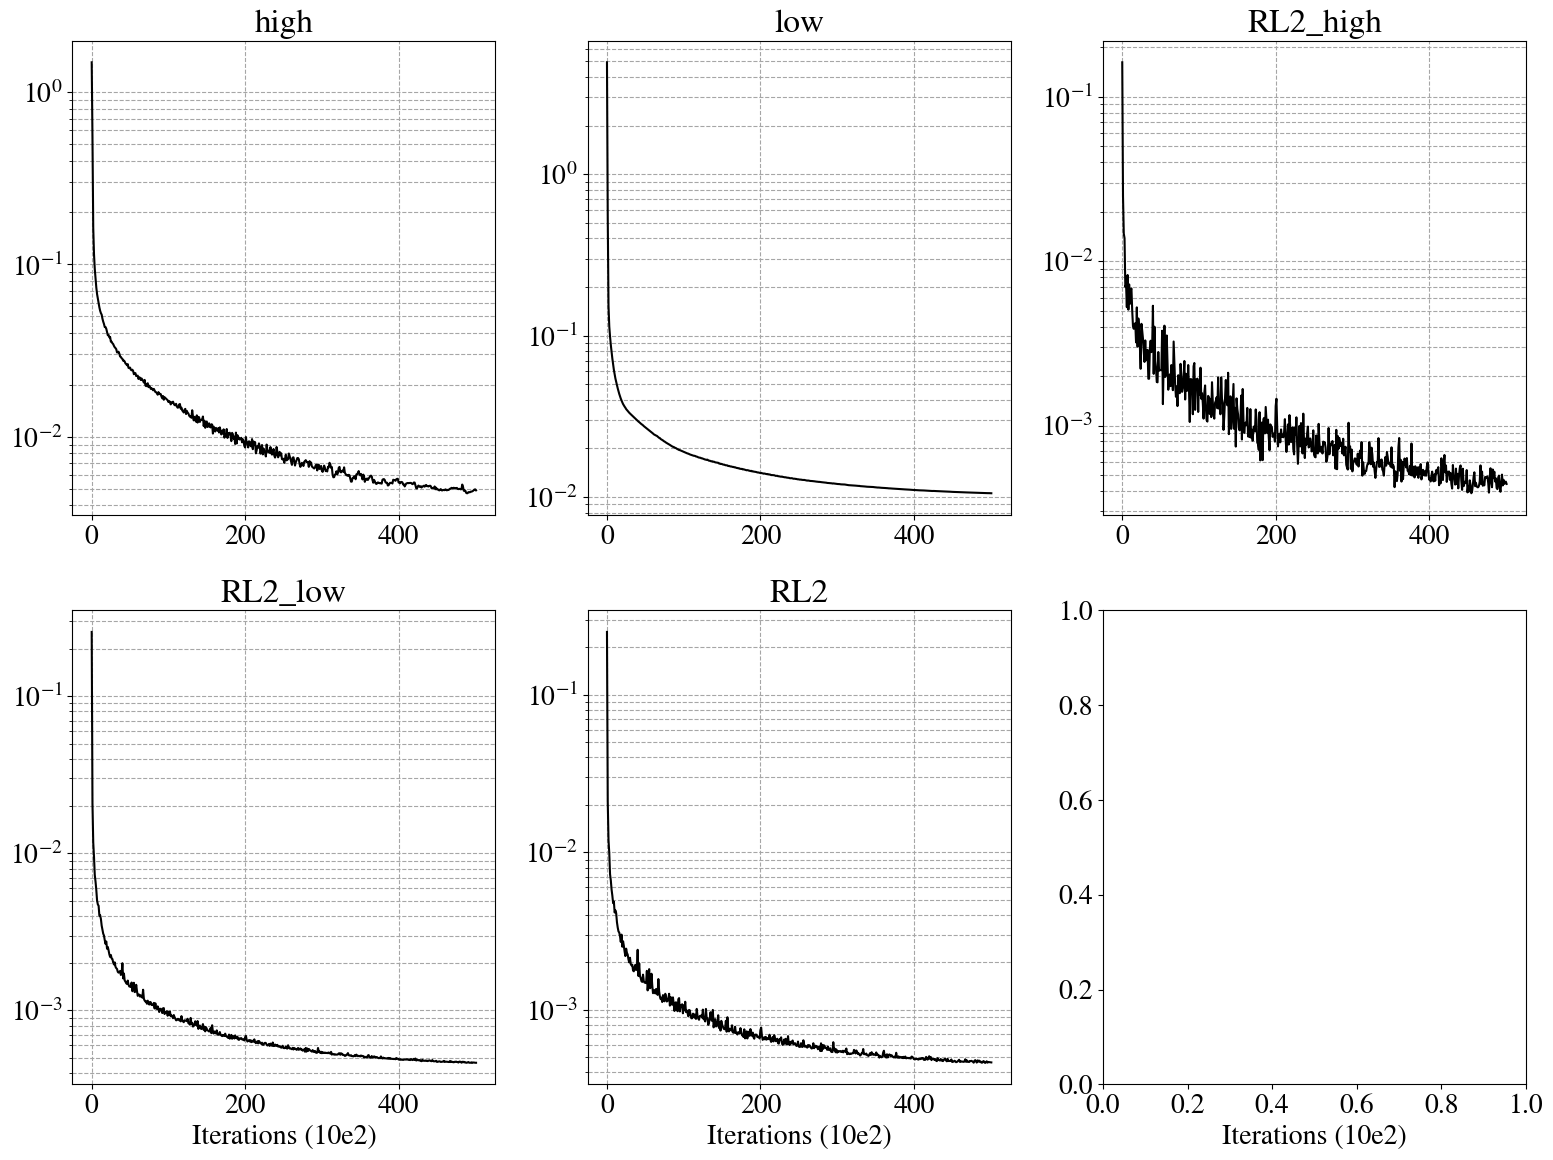

In [48]:
# Call the function
plot_losses_grid(log_loss)
plt.savefig(result_path + f'Losses.png')
plt.show()


# Plots

In [49]:
key='GT'
K_fx    = K_model(params)
# Further computations for errors if any
K_pred_log  = vmap(K_fx, (0))(dataset[key][:,0:layers_ref[0]])[:,None]
K_real_log=dataset[key][:,4:5]
error_K_log = np.abs(K_pred_log-K_real_log)
RL2_log = relative_error2(K_pred_log, K_real_log)
print(RL2_log)
K_pred = k_char*np.exp(K_pred_log+offset)
K_real =  k_char*np.exp(K_real_log+offset)
error_K = np.abs(K_pred-K_real)
RL2_K = relative_error2(K_pred, K_real)
print(K_pred.min(),K_pred.max())
print(RL2_K)

0.00046324269997038585
9.6456916e-17 1.0092615e-12
0.004091198099873427


Saved combined figure: /users/jdtoscan/Documents/Papers/Instant_AIV//Results/Permeability/Permeability_Init_K/Imgs/Combined_Midplanes_Final.png


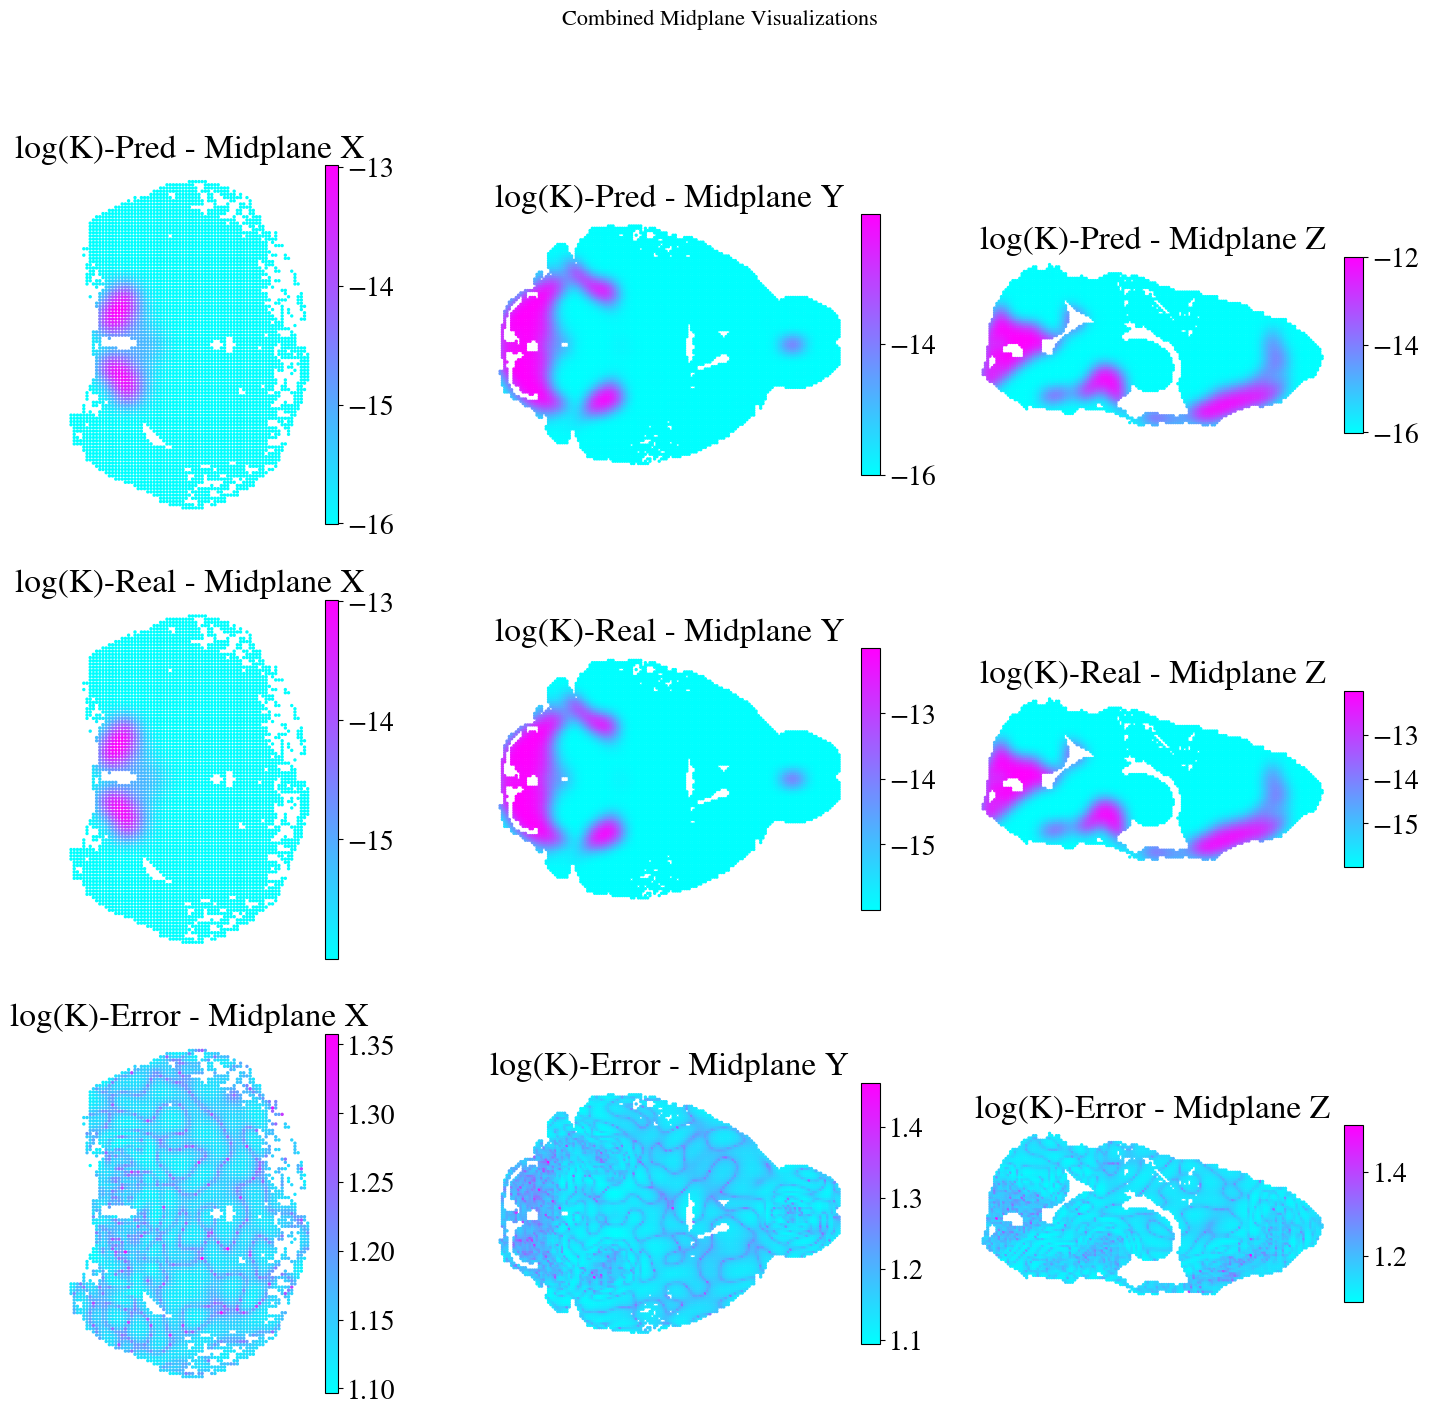

Finished generating combined plot.


In [50]:
t, x, y, z = dataset[key][:,0], dataset[key][:,1], dataset[key][:,2], dataset[key][:,3]

# Calculate midplane values
x_midplane = np.median(x)
y_midplane = np.median(y)
z_midplane = np.median(z)

# Define tolerance for midplane slice thickness
tolerance = 0.1  # Adjust based on your dataset's spread and units

# Define filters for each midplane
x_midplane_filter = np.abs(x - x_midplane) <= tolerance
y_midplane_filter = np.abs(y - y_midplane) <= tolerance
z_midplane_filter = np.abs(z - z_midplane) <= tolerance

# --- Prepare variables for plotting ---
# Using your exact original calculations
variables = [
    np.log10(K_pred),
    np.log10(K_real),
    np.log10(np.abs(K_pred - K_real)) / np.log10(K_real) # Your original error metric calculation
]
# Using variable names consistent with the 3 variables calculated
variable_names = ['log(K)-Pred','log(K)-Real','log(K)-Error']

num_variables = len(variables)
num_midplanes = 3 # X, Y, Z midplanes

# --- Create ONE Figure for all plots ---
fig = plt.figure(figsize=(15, 15)) # Adjust size as needed
fig.suptitle('Combined Midplane Visualizations', fontsize=16)

# --- Nested Loops for Plotting ---
# Outer loop: Variables (determines the row)
for i, var in enumerate(variables):

    # Inner loop: Midplanes (determines the column, using original j index 0, 1, 2)
    for j in range(num_midplanes):

        # Calculate subplot index (1-based)
        subplot_index = i * num_midplanes + j + 1

        # Add subplot to the single figure
        ax = fig.add_subplot(num_variables, num_midplanes, subplot_index)

        # --- Original Plotting Logic ---
        if j == 0: # X midplane, plot Y vs Z
            filter_mask = x_midplane_filter
            scatter_x_coords = y[filter_mask]
            scatter_y_coords = z[filter_mask]
            plane_label = "X"
        elif j == 1: # Y midplane, plot X vs Z
            filter_mask = y_midplane_filter
            scatter_x_coords = x[filter_mask]
            scatter_y_coords = z[filter_mask]
            plane_label = "Y"
        else:  # j == 2: Z midplane, plot X vs Y
            filter_mask = z_midplane_filter
            scatter_x_coords = x[filter_mask]
            scatter_y_coords = y[filter_mask]
            plane_label = "Z"

        scalar_values = var[filter_mask]

        # Using your exact scatter call and axis settings
        scatter = ax.scatter(scatter_x_coords, scatter_y_coords, c=scalar_values, cmap=cmap, s=2)
        ax.set_title(f'{variable_names[i]} - Midplane {plane_label}')
        ax.axis('equal')
        ax.axis('off')

        # Adding a colorbar using your original method and padding
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        plt.colorbar(scatter, cax=cax)
        # --- End of Original Plotting Logic ---


# --- Final Adjustments and Output ---
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save the single figure - Using simple string concatenation for the path
# *** ENSURE images_path DIRECTORY EXISTS BEFORE RUNNING ***
save_filename = images_path + 'Combined_Midplanes_Final.png' # Construct path as likely intended in original
plt.savefig(save_filename, dpi=150)
print(f"Saved combined figure: {save_filename}")

# Show the figure
plt.show()

print("Finished generating combined plot.")
